In [13]:
import pathlib
import random
import copy
import numpy as np
import torch
#import torchvision
from captum.attr import *
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import yaml
import argparse
from data.data_loader import load_eeg_data, get_sliding_window_data, create_dataloader
import os
import mne
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from scipy.fftpack import fft, ifft
from sliced_wasserstein import sliced_wasserstein_distance
from c2st import c2st_knn, c2st_nn, c2st_rf

from models.s4net import S4PatchedFinalNet,TrunkNet, HeadNet
from numba import jit
from scipy.integrate import simpson

In [3]:
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'x-large',
          'figure.titlesize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

In [4]:
CFG_YAML = """
wandb:
 key: f0c92a0059bf12e2647f0a1c22fdcd12555fa6df
model:
dataset:
 data_directory: /home/marco/Documents/GitHub/tms_eeg_decoding/data
 #file_name: subject_{:03d}_preprocessed_combined_py.fif
 file_name: subject_{:03d}_preprocessed_combined_py.fif
 exclude_timepoints: 100
 subject_index: 1
 test_subject_indices: [1,2,13,24,26,27,29,34,35,41, 42,43,45,46,47,48,52,55,56,57,60,62,67,69,72,73,79,80,86,88,92,102]
 #test_subject_indices: [2]
training:
 training_start_len: 100
 pretrain_epochs: 100
 pretrain_lr: 0.0001
 val_window_len: 1
 epochs_per_window: 10
 num_warmup_epochs: 5
 num_epochs: 800
 slide_step: 1
 num_warmup_epochs_per_window: 0
 lr: 0.005 #maybe change back to 0.0001
 nll_beta: 0.001
 num_warmup_epochs: 0
 batch_size: 50 #better to use 50
 random_seed: 42
 precision: bf16
 kde_lambda: 0.5
 finetune_entire_model: true # Set to true to finetune the entire model, false for transformer only
exp_name: S4_S4EEGNet_ema
"""

def load_config():
    cfg = OmegaConf.create(yaml.safe_load(CFG_YAML))
    cfg.exp_name = f"{cfg.exp_name}_subject_{cfg.dataset.subject_index}"
    return cfg

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--update_conf", nargs="*", help="Updates to the configuration in the form of key=value pairs", default=[])
    parser.add_argument("-f", "--fff", help="A dummy argument to handle IPython's default argument", default="1")
    return parser.parse_args()

def update_config(cfg, cli_args):
    for update in cli_args.update_conf:
        key, value = update.split("=")
        try:
            value = eval(value)
        except:
            pass
        OmegaConf.update(cfg, key, value, force_add=True)
    cfg.exp_name = cfg.exp_name + "_" + "_".join(cli_args.update_conf)
    print(OmegaConf.to_yaml(cfg))
    return cfg


def save_config(cfg):
    os.makedirs("conf/sweeps", exist_ok=True)
    os.makedirs("exp/withinsubs", exist_ok=True)
    with open(f"conf/sweeps/withinsubs_{cfg.exp_name}.yaml", "w") as f:
        f.write(OmegaConf.to_yaml(cfg))

In [5]:
cfg = load_config()

subject_index = cfg.dataset.test_subject_indices[1]
cfg.dataset.subject_index = subject_index
cfg.exp_name = f"S4_S4EEGNet_ema_100_cal_py_{cfg.dataset.subject_index}"
cli_args = parse_args()
cfg = update_config(cfg, cli_args)
save_config(cfg)
all_epochs, labels_raw, _, _, _, _, _, ch_names = load_eeg_data(cfg)
all_epochs = all_epochs[150:]
labels_raw = labels_raw[150:]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_shape_st = (60, 900)

wandb:
  key: f0c92a0059bf12e2647f0a1c22fdcd12555fa6df
model: null
dataset:
  data_directory: /home/marco/Documents/GitHub/tms_eeg_decoding/data
  file_name: subject_{:03d}_preprocessed_combined_py.fif
  exclude_timepoints: 100
  subject_index: 2
  test_subject_indices:
  - 1
  - 2
  - 13
  - 24
  - 26
  - 27
  - 29
  - 34
  - 35
  - 41
  - 42
  - 43
  - 45
  - 46
  - 47
  - 48
  - 52
  - 55
  - 56
  - 57
  - 60
  - 62
  - 67
  - 69
  - 72
  - 73
  - 79
  - 80
  - 86
  - 88
  - 92
  - 102
training:
  training_start_len: 100
  pretrain_epochs: 100
  pretrain_lr: 0.0001
  val_window_len: 1
  epochs_per_window: 10
  num_warmup_epochs: 0
  num_epochs: 800
  slide_step: 1
  num_warmup_epochs_per_window: 0
  lr: 0.005
  nll_beta: 0.001
  batch_size: 50
  random_seed: 42
  precision: bf16
  kde_lambda: 0.5
  finetune_entire_model: true
exp_name: S4_S4EEGNet_ema_100_cal_py_2_

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


In [6]:
def amplify_frequency_band(signal, sampling_rate, low_freq, high_freq, amplification_factor):
    # FFT
    freqs = np.fft.rfftfreq(len(signal), d=1/sampling_rate)
    fft_coeffs = np.fft.rfft(signal)

    # Amplify the specified frequency band
    band_mask = (freqs >= low_freq) & (freqs <= high_freq)
    fft_coeffs[band_mask] *= amplification_factor

    # Inverse FFT
    modified_signal = np.fft.irfft(fft_coeffs, n=len(signal))
    return modified_signal



In [7]:
def amplify_frequency_band_parallel_og(signals, sampling_rate, low_freq, high_freq, amplification_factor):
    # FFT
    freqs = np.fft.rfftfreq(signals.shape[2], d=1/sampling_rate)
    fft_coeffs = np.fft.rfft(signals, axis=2)


    # Amplify the specified frequency band
    band_mask = (freqs >= low_freq) & (freqs <= high_freq)
    for ch_idx in range(signals.shape[1]):
        fft_coeffs[ch_idx, ch_idx,band_mask] *= amplification_factor

    # Inverse FFT
    modified_signals = np.fft.irfft(fft_coeffs, n=signals.shape[2], axis=2)
    return modified_signals

In [66]:
def bandpower_paralell(data, sf, band, window_sec=None, relative=False):
    """Compute the average power of the signal x in a specific frequency band.

    Parameters
    ----------
    data : 1d-array
        Input signal in the time-domain.
    sf : float
        Sampling frequency of the data.
    band : list
        Lower and upper frequencies of the band of interest.
    window_sec : float
        Length of each window in seconds.
        If None, window_sec = (1 / min(band)) * 2
    relative : boolean
        If True, return the relative power (= divided by the total power of the signal).
        If False (default), return the absolute power.

    Return
    ------
    bp : float
        Absolute or relative band power.
    """

    band = np.asarray(band)
    low, high = band

    psd, freqs = mne.time_frequency.psd_array_multitaper(data, sf, fmin=low, fmax=high, adaptive=True, low_bias=True, normalization='full', verbose=False)
    

    # Frequency resolution
    #freq_res = freqs[1] - freqs[0]
    difference = np.diff(freqs)
    freq_res = np.mean(difference)

    # Find closest indices of band in frequency vector
    idx_band = np.logical_and(freqs >= low, freqs <= high)

    # Integral approximation of the spectrum using Simpson's rule.
    integral = simpson(psd[:,:,idx_band], dx=freq_res)
    average = np.mean(psd[:,:,idx_band])

    if relative:
        bp /= simpson(psd, dx=freq_res)
    return integral, average

In [9]:
def load_model(cfg, start_index=100, subject_index=2, rep=1):
    if rep ==1:
        save_path = "/home/marco/Documents/GitHub/tms_eeg_decoding/data/model_checkpoints/finetune"
        file_path = os.path.join(save_path, f"subject_{subject_index}", 
                           f"model_checkpoint_finetune_subject_index_{subject_index}_start_idx_{start_index}_rep_0_pen.pth") 
    else:
        save_path = f"/home/marco/Documents/GitHub/tms_eeg_decoding/data/model_checkpoints_rep_{rep}/finetune"
        file_path = os.path.join(save_path, f"subject_{subject_index}", 
                    f"model_checkpoint_finetune_subject_index_{subject_index}_start_idx_{start_index}_rep_{rep}_pen.pth") 

    trunk_net = TrunkNet(n_chans=input_shape_st[0], n_times=input_shape_st[1])
    head_net = HeadNet(64, 1)
    model = S4PatchedFinalNet(64, trunk_net, head_net)
    
    weights = torch.load(file_path)
    model.load_state_dict(weights)
    model.eval()
    model.to(device)
    return model


In [12]:
freq_bands = {"delta" : (0.5, 4),
            "theta": (4, 8),
              "alpha": (8, 12),
              "beta": (12, 30),
              "gamma": (30, 45)}
#amplification_factors = [0.2,0.5,2,3,5,10]

amplification_factors = [0.5,0.8,1.2,1.5]

In [11]:
def create_perturbed_samples_dict(all_epochs, freq_bands, phase_shifts):
    perturbed_samples_dict = {}

    for band_name, (low_freq, high_freq) in freq_bands.items():
        for amp_factor in amplification_factors:
            perturbed_samples = np.zeros_like(all_epochs)
            for sample in range(all_epochs.shape[0]):
                for ch in range(all_epochs.shape[1]):
                    perturbed_samples[sample, ch] = amplify_frequency_band(all_epochs[sample, ch], 1000, low_freq, high_freq, amp_factor)
            perturbed_samples_dict[f"{band_name}_{amp_factor}"] = perturbed_samples

    return perturbed_samples_dict


In [102]:
d0 = np.load("perturbed_prediction_dict_gamma_channel_amp_factor_1.5_subject_2.npy", allow_pickle=True).item()
d1 = np.load("/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples/parallel_perturbation/parallel_perturbed_prediction_dict_gamma_channel_amp_factor_1.5_subject_2.npy", allow_pickle=True).item()
d2 = np.load("/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples/parallel_perturbation/parallel_perturbed_prediction_dict_gamma_channel_amp_factor_1.5_subject_2_rep_1.npy", allow_pickle=True).item()

# index 0

In [14]:
model = load_model(cfg, start_index=100, subject_index=subject_index, rep=1)

/tmp/ipykernel_796909/1114802088.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(file_path)


In [18]:
all_signals = np.zeros( (60, 60, 900))               
for ch_idx in range(all_epochs.shape[1]):
    for ch_idx2 in range(all_epochs.shape[1]):
        all_signals[ch_idx,ch_idx2] = copy.deepcopy(all_epochs[0,ch_idx2])   
start_index = 100
perturbed_samples_start_index = amplify_frequency_band_parallel(all_signals, 1000, 30, 45, 1.5, windowing=True, transition=False)
print(model(torch.from_numpy(perturbed_samples_start_index[0]).unsqueeze(0).float().to(device)))

tensor[1, 2] μ=-0.085 σ=3.061 grad CatBackward0 cuda:0 [[2.080, -2.249]]


In [62]:
P,freqs = mne.time_frequency.psd_array_multitaper(perturbed_samples_start_index , 1000, fmin=30, fmax=45, adaptive=True, low_bias=True, normalization='full', verbose=False)

In [63]:
P.shape

(60, 60, 14)

In [61]:
bandpower(perturbed_samples_start_index, 1000, (30, 45), relative=True)

IndexError: boolean index did not match indexed array along dimension 0; dimension is 60 but corresponding boolean dimension is 14

In [47]:
idx_band

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [197]:
d2["Fp1"][0]

2.080047

In [153]:
all_signals = np.zeros( (60, 60, 900))               
for ch_idx in range(all_epochs.shape[1]):
    for ch_idx2 in range(all_epochs.shape[1]):
        all_signals[ch_idx,ch_idx2] = copy.deepcopy(all_epochs[0,ch_idx2])   
start_index = 100
perturbed_samples_start_index = amplify_frequency_band_parallel_og(all_signals, 1000, 30, 45, 1.5)
print(model(torch.from_numpy(perturbed_samples_start_index[0]).unsqueeze(0).float().to(device)))

tensor[1, 2] μ=0.372 σ=3.206 grad CatBackward0 cuda:0 [[2.639, -1.895]]


In [157]:
d1["Fp1"][0]

2.6391768

In [154]:
all_signals2 = np.zeros( (60, 60, 900))               
for ch_idx in range(all_epochs.shape[1]):
    for ch_idx2 in range(all_epochs.shape[1]):
        all_signals2[ch_idx,ch_idx2] = copy.deepcopy(all_epochs[0,ch_idx2])   
start_index = 100

perturbed_samples_start_index2 = np.zeros_like(all_signals2)

for ch_idx in range(all_epochs.shape[1]):
    all_signals2[ch_idx, ch_idx] = amplify_frequency_band(all_signals2[ch_idx, ch_idx], 1000, 30, 45, 1.5)
model(torch.from_numpy(all_signals2[0]).unsqueeze(0).float().to(device))

tensor[1, 2] μ=0.372 σ=3.206 grad CatBackward0 cuda:0 [[2.639, -1.895]]

In [160]:
d0["Fp1"][0][0]

2.6391773223876953

In [12]:
model(torch.from_numpy(all_epochs[0]).unsqueeze(0).float().to(device))

tensor[1, 2] μ=0.389 σ=3.237 grad CatBackward0 cuda:0 [[2.678, -1.899]]

In [13]:
window = np.hanning(900)
windowed_signal = all_epochs[0] * window
og_signal = windowed_signal / np.mean(window)
model(torch.from_numpy(og_signal).unsqueeze(0).float().to(device))

tensor[1, 2] μ=0.058 σ=3.174 grad CatBackward0 cuda:0 [[2.302, -2.186]]

In [15]:
window = np.hanning(900)
windowed_signal = all_epochs[0] * window
og_signal = windowed_signal / np.mean(window)
model(torch.from_numpy(og_signal).unsqueeze(0).float().to(device))

tensor[1, 2] μ=0.058 σ=3.174 grad CatBackward0 cuda:0 [[2.302, -2.186]]

In [16]:
window = np.hamming(900)
windowed_signal = all_epochs[0] * window
og_signal = windowed_signal / np.mean(window)
model(torch.from_numpy(og_signal).unsqueeze(0).float().to(device))

tensor[1, 2] μ=0.097 σ=3.216 grad CatBackward0 cuda:0 [[2.371, -2.178]]

In [18]:
window = np.blackman(900)
windowed_signal = all_epochs[0] * window
og_signal = windowed_signal / np.mean(window)
model(torch.from_numpy(og_signal).unsqueeze(0).float().to(device))

tensor[1, 2] μ=-0.115 σ=2.959 grad CatBackward0 cuda:0 [[1.977, -2.208]]

# index 1

In [161]:
model = load_model(cfg, start_index=101, subject_index=subject_index, rep=1)

/tmp/ipykernel_3068087/1114802088.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(file_path)


In [166]:
all_signals = np.zeros( (60, 60, 900))               
for ch_idx in range(all_epochs.shape[1]):
    for ch_idx2 in range(all_epochs.shape[1]):
        all_signals[ch_idx,ch_idx2] = copy.deepcopy(all_epochs[1,ch_idx2])   
start_index = 100
perturbed_samples_start_index = amplify_frequency_band_parallel(all_signals, 1000, 30, 45, 1.5)
print(model(torch.from_numpy(perturbed_samples_start_index[0]).unsqueeze(0).float().to(device)))

tensor[1, 2] μ=-1.228 σ=0.525 grad CatBackward0 cuda:0 [[-1.599, -0.857]]


In [167]:
d2["Fp1"][1]

-1.6080066

In [168]:
all_signals = np.zeros( (60, 60, 900))               
for ch_idx in range(all_epochs.shape[1]):
    for ch_idx2 in range(all_epochs.shape[1]):
        all_signals[ch_idx,ch_idx2] = copy.deepcopy(all_epochs[1,ch_idx2])   
start_index = 100
perturbed_samples_start_index = amplify_frequency_band_parallel_og(all_signals, 1000, 30, 45, 1.5)
print(model(torch.from_numpy(perturbed_samples_start_index[0]).unsqueeze(0).float().to(device)))

tensor[1, 2] μ=-1.314 σ=1.932 grad CatBackward0 cuda:0 [[0.052, -2.681]]


In [169]:
d1["Fp1"][1]

0.051939324

In [172]:
all_signals2 = np.zeros( (60, 60, 900))               
for ch_idx in range(all_epochs.shape[1]):
    for ch_idx2 in range(all_epochs.shape[1]):
        all_signals2[ch_idx,ch_idx2] = copy.deepcopy(all_epochs[1,ch_idx2])   
start_index = 100

perturbed_samples_start_index2 = np.zeros_like(all_signals2)

for ch_idx in range(all_epochs.shape[1]):
    all_signals2[ch_idx, ch_idx] = amplify_frequency_band(all_signals2[ch_idx, ch_idx], 1000, 30, 45, 1.5)
model(torch.from_numpy(all_signals2[0]).unsqueeze(0).float().to(device))

tensor[1, 2] μ=-1.314 σ=1.932 grad CatBackward0 cuda:0 [[0.052, -2.681]]

In [171]:
d0["Fp1"][0][1]

0.05193951725959778

@jit
def amplify_frequency_band_parallel_broken(signals, sampling_rate, low_freq, high_freq, amplification_factors, freqs):
    # input signal need to be of shape ((amp_factors, 60, 60, 900)) of which all entries in 60, 900 are the deepcopied version of the original signal
    perturbed_signals = np.zeros_like(signals)
    for amp_factor_idx,amp_factor in enumerate(amplification_factors):
        for ch_idx in range(signals.shape[0]):
            peturbed_signal = signals[amp_factor_idx][ch_idx]
            channel_signal = peturbed_signal[ch_idx]
            #freqs = np.fft.rfftfreq(len(channel_signal), d=1/sampling_rate)
            fft_coeffs = np.fft.fft(channel_signal)
            band_mask = (freqs >= low_freq) & (freqs <= high_freq)
            fft_coeffs[band_mask] *= amp_factor
            peturbed_signal[ch_idx] = np.fft.irfft(fft_coeffs, n=len(channel_signal))
            perturbed_signals[amp_factor][ch_idx] = peturbed_signal

    return perturbed_signals
    

# start

In [16]:
def amplify_frequency_band_parallel(signals, sampling_rate, low_freq, high_freq, amplification_factor, window_type='hamming', transition_width=1.1, windowing=True, transition=True):


    n = signals.shape[2]  # number of time points
    if window_type.lower() == 'hann':
        window = np.hanning(n)
    elif window_type.lower() == 'hamming':
        window = np.hamming(n)
    elif window_type.lower() == 'blackman':
        window = np.blackman(n)
    else:  # 'none' or any invalid window type
        window = np.ones(n)
    
    # Apply window to each signal (broadcasting across all channels)
    if windowing:
        windowed_signals = signals * window[np.newaxis, np.newaxis, :]
    else:
        windowed_signals = signals
    freqs = np.fft.rfftfreq(signals.shape[2], d=1/sampling_rate)
    fft_coeffs = np.fft.rfft(signals, axis=2)

    lower_transition_start = max(0, low_freq - transition_width)
    lower_transition_end = low_freq
    upper_transition_start = high_freq
    upper_transition_end = high_freq + transition_width

    amplification_mask = np.ones(len(freqs))
    main_band_mask = (freqs >= low_freq) & (freqs <= high_freq)
    amplification_mask[main_band_mask] = amplification_factor

    if transition:
        if lower_transition_start < lower_transition_end:
            lower_transition_mask = (freqs >= lower_transition_start) & (freqs < lower_transition_end)
            transition_positions = (freqs[lower_transition_mask] - lower_transition_start) / (lower_transition_end - lower_transition_start)
            amplification_mask[lower_transition_mask] = 1 + (amplification_factor - 1) * transition_positions
    
    # Define mask for upper transition band (linear ramp)
   
        if upper_transition_start < upper_transition_end:
            upper_transition_mask = (freqs > upper_transition_start) & (freqs <= upper_transition_end)
            transition_positions = (freqs[upper_transition_mask] - upper_transition_start) / (upper_transition_end - upper_transition_start)
            amplification_mask[upper_transition_mask] = amplification_factor - (amplification_factor - 1) * transition_positions

    # Amplify the specified frequency band
    for ch_idx in range(signals.shape[0]):
        fft_coeffs[ch_idx, ch_idx, :] *= amplification_mask
    #band_mask = (freqs >= low_freq) & (freqs <= high_freq)
    #for ch_idx in range(signals.shape[1]):
    #    fft_coeffs[ch_idx, ch_idx,band_mask] *= amplification_factor

    # Inverse FFT
    modified_signals = np.fft.irfft(fft_coeffs, n=signals.shape[2], axis=2)
    if windowing:
        modified_signals = modified_signals / np.mean(window)
    #modified_signals = modified_signals / np.mean(window)
   
    return modified_signals


In [71]:
def bandpower(data, sf, band, window_sec=None, relative=False):
    """Compute the average power of the signal x in a specific frequency band.

    Parameters
    ----------
    data : 1d-array
        Input signal in the time-domain.
    sf : float
        Sampling frequency of the data.
    band : list
        Lower and upper frequencies of the band of interest.
    window_sec : float
        Length of each window in seconds.
        If None, window_sec = (1 / min(band)) * 2
    relative : boolean
        If True, return the relative power (= divided by the total power of the signal).
        If False (default), return the absolute power.

    Return
    ------
    bp : float
        Absolute or relative band power.
    """

    band = np.asarray(band)
    low, high = band

    psd, freqs = mne.time_frequency.psd_array_multitaper(data, sf, fmin=low, fmax=high, adaptive=True, low_bias=True, normalization='full', verbose=False)
    

    # Frequency resolution
    #freq_res = freqs[1] - freqs[0]
    difference = np.diff(freqs)
    freq_res = np.mean(difference)

    # Find closest indices of band in frequency vector
    idx_band = np.logical_and(freqs >= low, freqs <= high)

    # Integral approximation of the spectrum using Simpson's rule.
    integral = simpson(psd[idx_band], dx=freq_res)
    average = np.mean(psd[idx_band])

    if relative:
        bp /= simpson(psd, dx=freq_res)
    return integral, average

## test

In [204]:
all_signals_test1 = np.zeros((2,2,900))
for i in range(2):
    for j in range(2):
        all_signals_test1[i,j] = copy.deepcopy(all_epochs[0,j])
        perturbed_singals1 = amplify_frequency_band_parallel(all_signals_test1, 1000, 30, 45, 1.5, window_type="hammig")

In [205]:
all_signals_test2 = np.zeros((2,2,900))
for i in range(2):
    for j in range(2):
        all_signals_test2[i,j] = copy.deepcopy(all_epochs[0,j])
        perturbed_singals2 = amplify_frequency_band_parallel_og(all_signals_test1, 1000, 30, 45, 1.5)

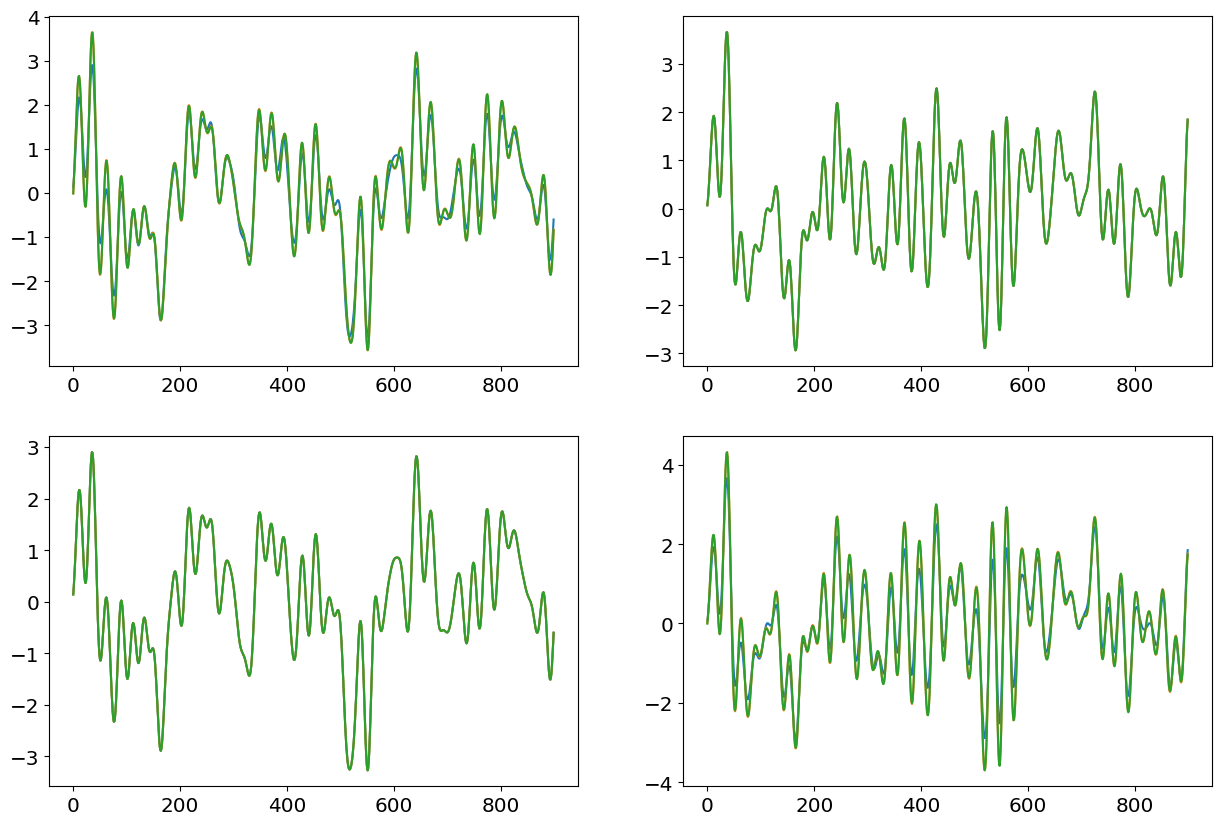

In [206]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
for i in range(2):
    for j in range(2):
        axs[i,j].plot(all_signals_test1[i,j])
        axs[i,j].plot(perturbed_singals1[i,j])
        axs[i,j].plot(perturbed_singals2[i,j])

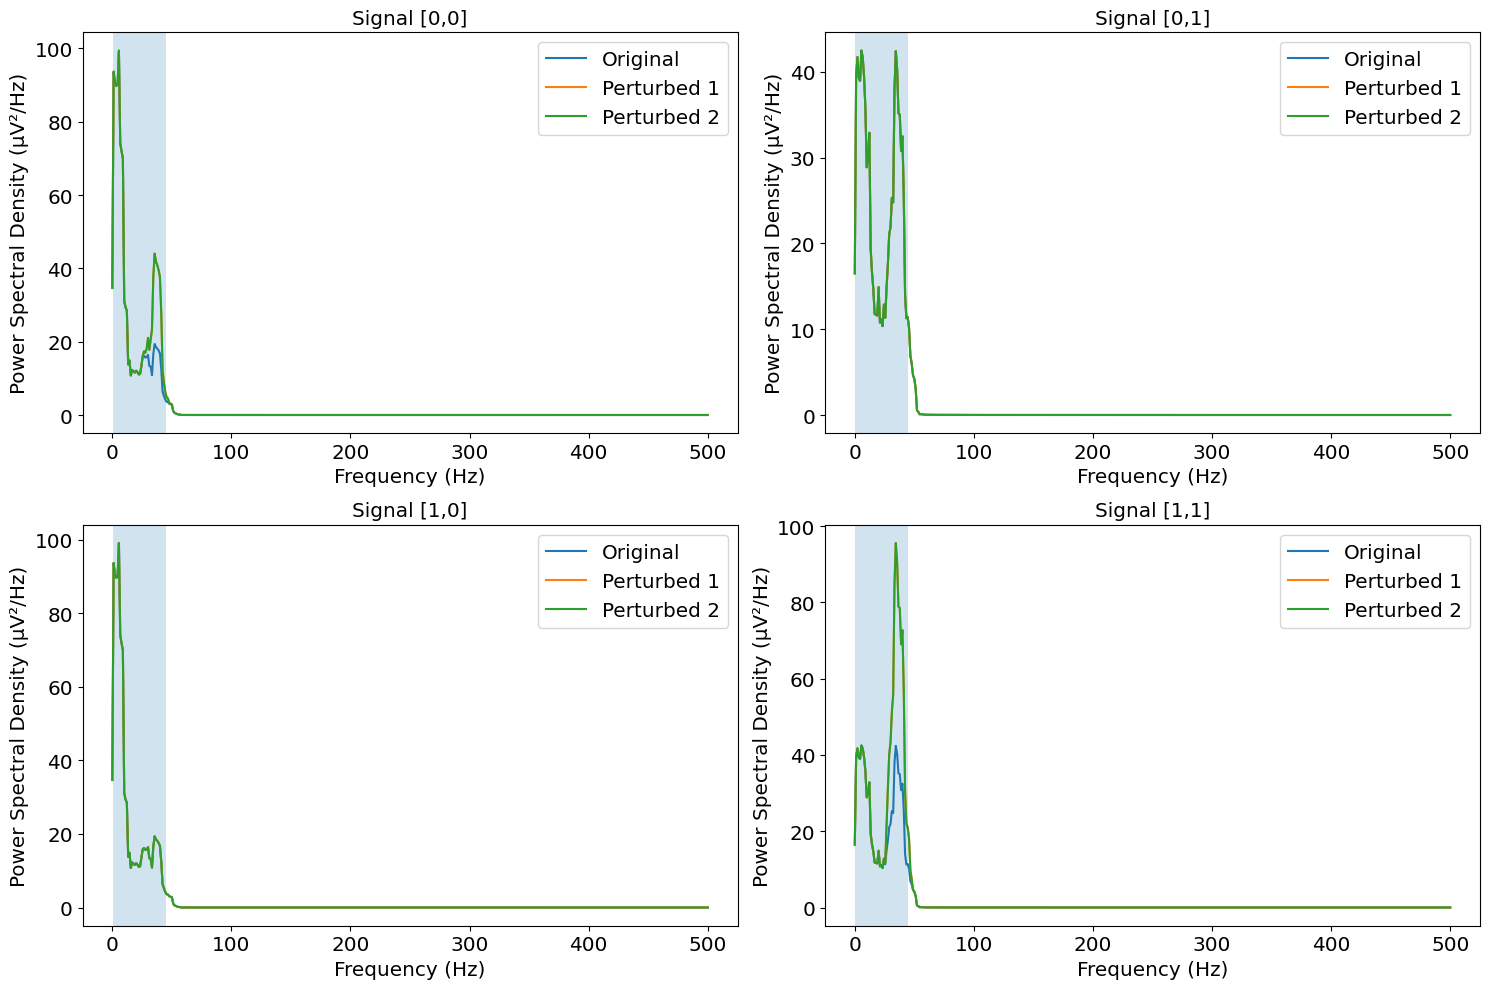

In [207]:
def plot_multitaper_psd(signals, perturbed1, perturbed2, sfreq=1000, fmin=0, fmax=50):
    """
    Plot multitaper PSD for original and perturbed signals
    """
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    
    for i in range(2):
        for j in range(2):
            # Create info for raw object
      
            
            # Compute PSD using multitaper method
            psd_orig, freqs = mne.time_frequency.psd_array_multitaper(signals[i,j], fmin=fmin, fmax=fmax, 
                                                              n_jobs=1, verbose=False, sfreq=1000)
            psd_pert1, _ = mne.time_frequency.psd_array_multitaper(perturbed1[i,j], fmin=fmin, fmax=fmax, 
                                                           n_jobs=1, verbose=False, sfreq=1000)
            psd_pert2, _ = mne.time_frequency.psd_array_multitaper(perturbed2[i,j], fmin=fmin, fmax=fmax, 
                                                           n_jobs=1, verbose=False, sfreq=1000)
            
            # Plot PSDs
            axs[i, j].plot(freqs, psd_orig, label='Original')
            axs[i, j].plot(freqs, psd_pert1, label='Perturbed 1')
            axs[i, j].plot(freqs, psd_pert2, label='Perturbed 2')
            axs[i, j].set_title(f'Signal [{i},{j}]')
            axs[i, j].set_xlabel('Frequency (Hz)')
            axs[i, j].set_ylabel('Power Spectral Density (µV²/Hz)')
            axs[i, j].legend()
            
            # Highlight frequency bands
            for band_name, (low_freq, high_freq) in freq_bands.items():
                axs[i, j].axvspan(low_freq, high_freq, alpha=0.2, label=band_name)
    
    plt.tight_layout()
    #return fig

# Plot PSDs of original and perturbed signals
plot_multitaper_psd(all_signals_test1, perturbed_singals1, perturbed_singals2, fmax=2000)

# evaluation

In [ ]:
def generate_perturbed_predictions_parallel(all_epochs, freq_bands, amplification_factors, ch_names, subject_index, device, cfg, rep=1):
    save_dir = "parallel_perturbation"
    save_dir_distance = "parallel_perturbation_distance"
    perturbed_prediction_dict = {}
    distance_dict = {}
    for band_name, (low_freq, high_freq) in freq_bands.items():
        #print(band_name)
        for amp_factor in amplification_factors:
            perturbed_channel_wise = {ch: [ ]for ch in ch_names}
            uncertainty_channel_wise = {ch: [ ]for ch in ch_names}
            distance_channel_wise = {ch: [ ]for ch in ch_names}
            for sample in range(all_epochs.shape[0]):
                all_signals = np.zeros( (60, 60, 900))               
                for ch_idx in range(all_epochs.shape[1]):
                    for ch_idx2 in range(all_epochs.shape[1]):
                        all_signals[ch_idx,ch_idx2] = copy.deepcopy(all_epochs[sample,ch_idx2])   
                start_index = sample + 100
                perturbed_samples_start_index = amplify_frequency_band_parallel(all_signals, 1000, low_freq, high_freq, amp_factor, transition=True, windowing=False)
                inputs = torch.from_numpy(perturbed_samples_start_index)
                inputs = inputs.to(device).float()
                #distance = np.linalg.norm(perturbed_samples_start_index - all_epochs[sample])
                integral_perturbed = bandpower_paralell(perturbed_samples_start_index, 1000, (low_freq, high_freq), relative=True)
                integral_original = bandpower(all_epochs[sample], 1000, (low_freq, high_freq), relative=True)
                distance = integral_original-integral_perturbed
                model = load_model(cfg, start_index=start_index, subject_index=subject_index, rep=rep)
                output = model(inputs)
                pred_means = output[:, 0]
                #log_vars = output[:, 1]
               
                pred_labels_perturbed = pred_means.cpu().detach().numpy()
                #pred_uncertainty = np.exp(log_vars.cpu().detach().numpy())
 
                for ch_idx,ch_name in enumerate(ch_names):
                    perturbed_channel_wise[ch_name].append(pred_labels_perturbed[ch_idx])
                    #uncertainty_channel_wise[ch_name].append(pred_uncertainty[ch_idx])
                    distance_channel_wise[ch_name].append(distance)
            perturbed_prediction_dict[f"band_{band_name}_amp_factor_{amp_factor}"] = perturbed_channel_wise
            distance_dict[f"band_{band_name}_amp_factor_{amp_factor}"] = distance_channel_wise
            
            os.makedirs(save_dir, exist_ok=True)
            save_file = f"parallel_perturbed_prediction_dict_{band_name}_channel_amp_factor_{amp_factor}_subject_{subject_index}_rep_{rep}.npy"
            save_path = os.path.join(save_dir, save_file)
            os.makedirs(save_dir_distance, exist_ok=True)
            save_file_distance = f"parallel_distance_dict_{band_name}_channel_amp_factor_{amp_factor}_subject_{subject_index}_rep_{rep}.npy"
            save_path_distance = os.path.join(save_dir_distance, save_file_distance)
            np.save(save_path, perturbed_channel_wise)
            np.save(save_path_distance, distance_channel_wise)
            
    
    #return perturbed_prediction_dict

redo using rep [0,1], get distances for these

In [50]:
for rep in [0]:
    all_subjects_perturbed_predictions = {}
    cfg = load_config()
    for subject_index in cfg.dataset.test_subject_indices:
        cfg.dataset.subject_index = subject_index
        cfg.exp_name = f"S4_S4EEGNet_ema_100_cal_py_{cfg.dataset.subject_index}"
        all_epochs, labels_raw, _, _, _, _, _, ch_names = load_eeg_data(cfg)
        all_epochs = all_epochs[150:]
        labels_raw = labels_raw[150:]
        print("all epochs shape", all_epochs.shape)
    
        generate_perturbed_predictions_parallel(all_epochs, freq_bands, amplification_factors, ch_names, subject_index, device, cfg, rep=rep+1)
    #np.save(f"perturbed_predictions_subject_{subject_index}_channel_wise.npy", perturbed_predictions)

# Save the results
#np.save("all_subjects_perturbed_predictions.npy", all_subjects_perturbed_predictions)

Loading EEG data...
(100, 60, 900)
(1, 60, 1)
all epochs shape (360, 60, 900)


/tmp/ipykernel_3135991/1114802088.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(file_path)


Loading EEG data...
(100, 60, 900)
(1, 60, 1)
all epochs shape (571, 60, 900)


/tmp/ipykernel_3135991/1114802088.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(file_path)


Loading EEG data...
(100, 60, 900)
(1, 60, 1)
all epochs shape (483, 60, 900)


...

/tmp/ipykernel_3135991/1114802088.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(file_path)


Loading EEG data...
(100, 60, 900)
(1, 60, 1)
all epochs shape (414, 60, 900)


/tmp/ipykernel_3135991/1114802088.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(file_path)


Loading EEG data...
(100, 60, 900)
(1, 60, 1)
all epochs shape (639, 60, 900)


/tmp/ipykernel_3135991/1114802088.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(file_path)
